# Chicago Crimes EDA — Citywide Analysis

**Scope:** All 77 community areas across Chicago  
**Period:** Last 6 months  
**Data Source:** [Chicago Data Portal — Crimes 2001 to Present](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2)

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sodapy import Socrata
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14

APP_TOKEN = 'Dpp1StQZt6kUf8cPF3eI4epyA'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Community Area Code → Name Mapping (All 77 Areas)

In [3]:
import requests
import pandas as pd

# Fetch official Community Area number -> name mapping from Chicago Data Portal
resp = requests.get(
    "https://data.cityofchicago.org/resource/igwz-8jzy.json?$limit=100",
    verify=False
)
resp.raise_for_status()

COMMUNITY_AREAS = {
    int(r["area_numbe"]): r["community"].title()
    for r in resp.json()
}

print(f"Total community areas fetched: {len(COMMUNITY_AREAS)}")

# Display as a sorted table
mapping_df = (
    pd.DataFrame(list(COMMUNITY_AREAS.items()), columns=["Area Code", "Neighborhood"])
    .sort_values("Area Code")
    .reset_index(drop=True)
)
mapping_df

Total community areas fetched: 77


,Area Code,Neighborhood
0,1,Rogers Park
1,2,West Ridge
2,3,Uptown
3,4,Lincoln Square
4,5,North Center
...,...,...
72,73,Washington Heights
73,74,Mount Greenwood
74,75,Morgan Park
75,76,Ohare


## 3. Fetch Full Year (Last 12 Months) of Citywide Crime Data

In [4]:
one_year_ago = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%dT00:00:00.000')
today          = datetime.now().strftime('%Y-%m-%d')

soql_where = f"date >= '{one_year_ago}'"

print(f'Fetching data from : {one_year_ago[:10]}  →  {today}')
print(f'SoQL WHERE clause  : {soql_where}')

Fetching data from : 2025-04-01  →  2026-04-01
SoQL WHERE clause  : date >= '2025-04-01T00:00:00.000'


In [5]:
client = Socrata('data.cityofchicago.org', APP_TOKEN)

print('Fetching records …')
results = client.get(
    'ijzp-q8t2',
    where=soql_where,
    limit=500_000,
    order='date DESC'
)

df_raw = pd.DataFrame.from_records(results)
print(f'Records fetched : {len(df_raw):,}')
print(f'Columns         : {list(df_raw.columns)}')

Fetching records …
Records fetched : 228,362
Columns         : ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


## 4. Data Cleaning & Type Casting

In [6]:
df = df_raw.copy()

# ── Date / time ────────────────────────────────────────────────
df['date']        = pd.to_datetime(df['date'], errors='coerce')
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b %Y')
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend']  = df['date'].dt.dayofweek >= 5

# ── Numeric coercions ─────────────────────────────────────────
for col in ['community_area', 'beat', 'district', 'ward']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['latitude', 'longitude', 'x_coordinate', 'y_coordinate']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Boolean ───────────────────────────────────────────────────
for col in ['arrest', 'domestic']:
    if col in df.columns:
        df[col] = df[col].map({'true': True, 'false': False, True: True, False: False})

# ── Neighborhood label ────────────────────────────────────────
df['neighborhood'] = df['community_area'].map(COMMUNITY_AREAS).fillna('Unknown')

# ── String normalisation ──────────────────────────────────────
for col in ['primary_type', 'description', 'location_description', 'block']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.upper()

print(f'Shape after cleaning : {df.shape}')
print(f'Date range           : {df["date"].min()} → {df["date"].max()}')
print(f'Unique neighborhoods : {df["neighborhood"].nunique()}')
print(f'Null values (non-zero):\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape after cleaning : (228362, 28)
Date range           : 2025-04-01 00:00:00 → 2026-03-24 00:00:00
Unique neighborhoods : 78
Null values (non-zero):
location_description    1083
ward                       1
community_area             9
x_coordinate              97
y_coordinate              97
latitude                  97
longitude                 97
location                  97
dtype: int64


## 5. Dataset Overview

In [7]:
print('=== Shape ===')
print(df.shape)

print('\n=== dtypes ===')
print(df.dtypes)

print('\n=== First 5 rows ===')
df.head()

=== Shape ===
(228362, 28)

=== dtypes ===
id                                 str
case_number                        str
date                    datetime64[us]
block                              str
iucr                               str
primary_type                       str
description                        str
location_description               str
arrest                            bool
domestic                          bool
beat                             int64
district                         int64
ward                           float64
community_area                 float64
fbi_code                           str
x_coordinate                   float64
y_coordinate                   float64
year                             int32
updated_on                         str
latitude                       float64
longitude                      float64
location                        object
month                            int32
month_name                         str
hour                 

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,month,month_name,hour,day_of_week,is_weekend,neighborhood
0,14146008,JK192371,2026-03-24,064XX S EBERHART AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,2026-03-31T15:46:18.000,41.777733,-87.613148,"{'latitude': '41.777732596', 'longitude': '-87...",3,Mar 2026,0,Tuesday,False,Woodlawn
1,14150220,JK197548,2026-03-24,132XX S BUFFALO AVE,0920,MOTOR VEHICLE THEFT,ATTEMPT - AUTOMOBILE,STREET,False,False,...,2026-03-31T15:46:18.000,41.655024,-87.543515,"{'latitude': '41.655024021', 'longitude': '-87...",3,Mar 2026,0,Tuesday,False,Hegewisch
2,14146098,JK192492,2026-03-24,047XX W GRAND AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,...,2026-03-31T15:46:18.000,41.913243,-87.744294,"{'latitude': '41.913242541', 'longitude': '-87...",3,Mar 2026,0,Tuesday,False,Austin
3,14151289,JK198625,2026-03-24,089XX S HOUSTON AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,APARTMENT,False,False,...,2026-03-31T15:46:18.000,NaN,NaN,NaN,3,Mar 2026,0,Tuesday,False,South Chicago
4,14145924,JK192341,2026-03-24,020XX W WAVELAND AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,2026-03-31T15:46:18.000,41.948678,-87.679299,"{'latitude': '41.948678136', 'longitude': '-87...",3,Mar 2026,0,Tuesday,False,North Center


In [ ]:
print('=== Basic statistics ===')
df.describe(include='all')

=== Basic statistics ===


## 6. Missing Value Analysis

                      missing_count  missing_%
location_description           1083       0.47
y_coordinate                     97       0.04
location                         97       0.04
longitude                        97       0.04
latitude                         97       0.04
x_coordinate                     97       0.04
community_area                    9       0.00
ward                              1       0.00


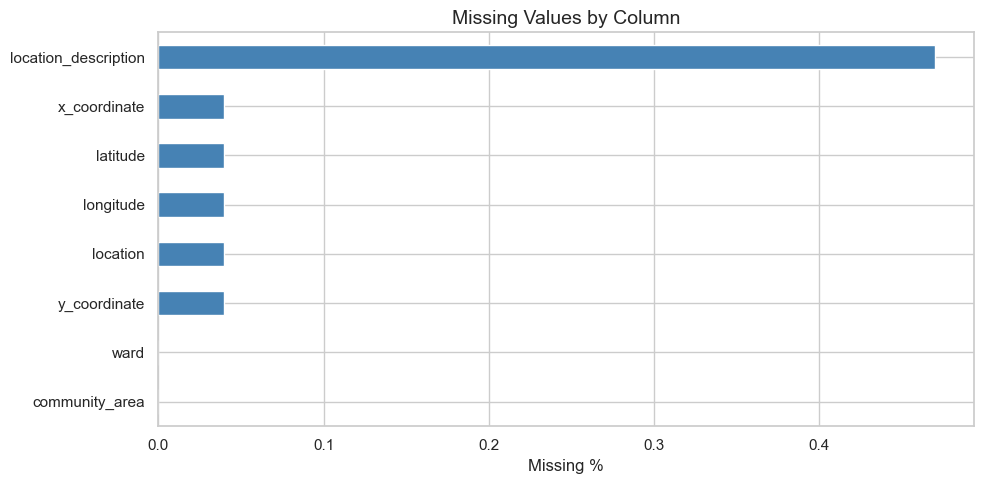

In [8]:
missing     = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df  = missing_df[missing_df['missing_count'] > 0]

print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['missing_%'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

## 7. Citywide Crime Count — Top 20 Neighborhoods

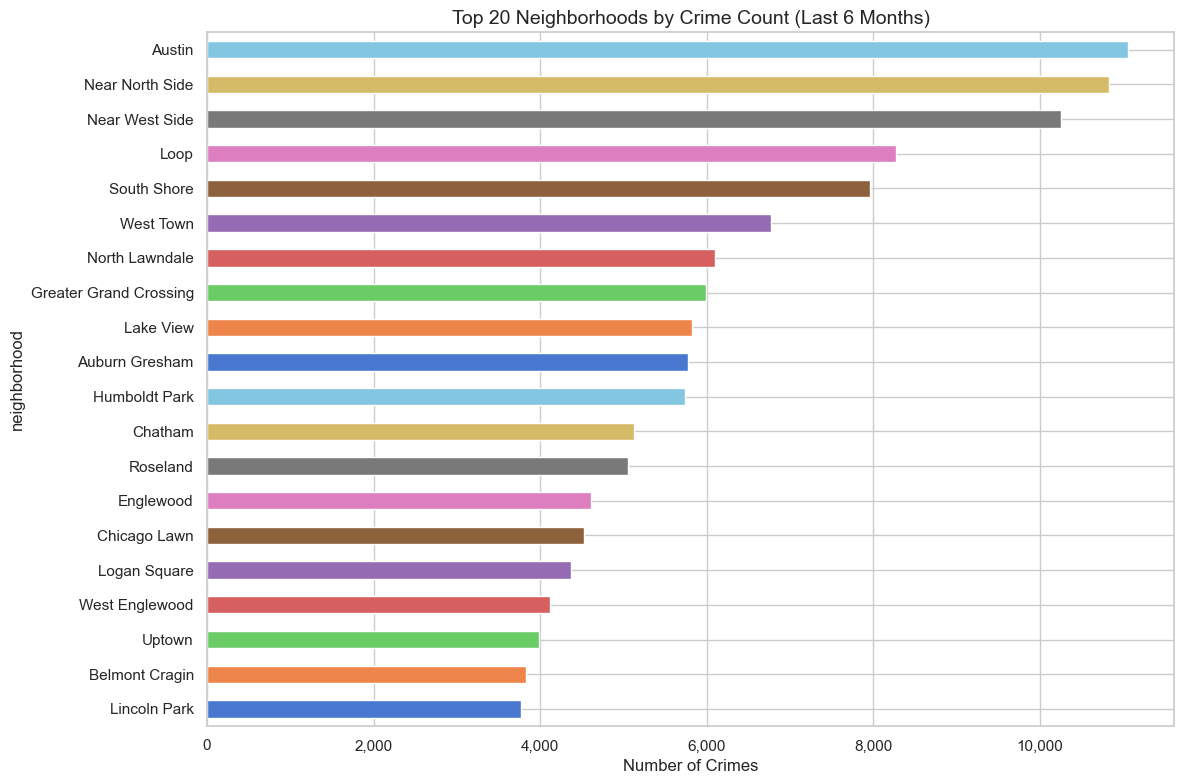


All neighborhoods ranked:
neighborhood
Austin                    11056
Near North Side           10826
Near West Side            10254
Loop                       8275
South Shore                7963
West Town                  6766
North Lawndale             6100
Greater Grand Crossing     5992
Lake View                  5825
Auburn Gresham             5778
Humboldt Park              5739
Chatham                    5122
Roseland                   5057
Englewood                  4604
Chicago Lawn               4522
Logan Square               4369
West Englewood             4116
Uptown                     3982
Belmont Cragin             3828
Lincoln Park               3774
Woodlawn                   3632
South Chicago              3615
South Lawndale             3589
East Garfield Park         3547
Rogers Park                3531
New City                   3485
Grand Boulevard            3341
West Garfield Park         3209
West Ridge                 3115
West Pullman               3072


In [9]:
hood_counts = df['neighborhood'].value_counts().head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
hood_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', 20))
ax.set_xlabel('Number of Crimes')
ax.set_title('Top 20 Neighborhoods by Crime Count (Last 6 Months)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('\nAll neighborhoods ranked:')
print(df['neighborhood'].value_counts().to_string())

## 8. Top Crime Types (Citywide)

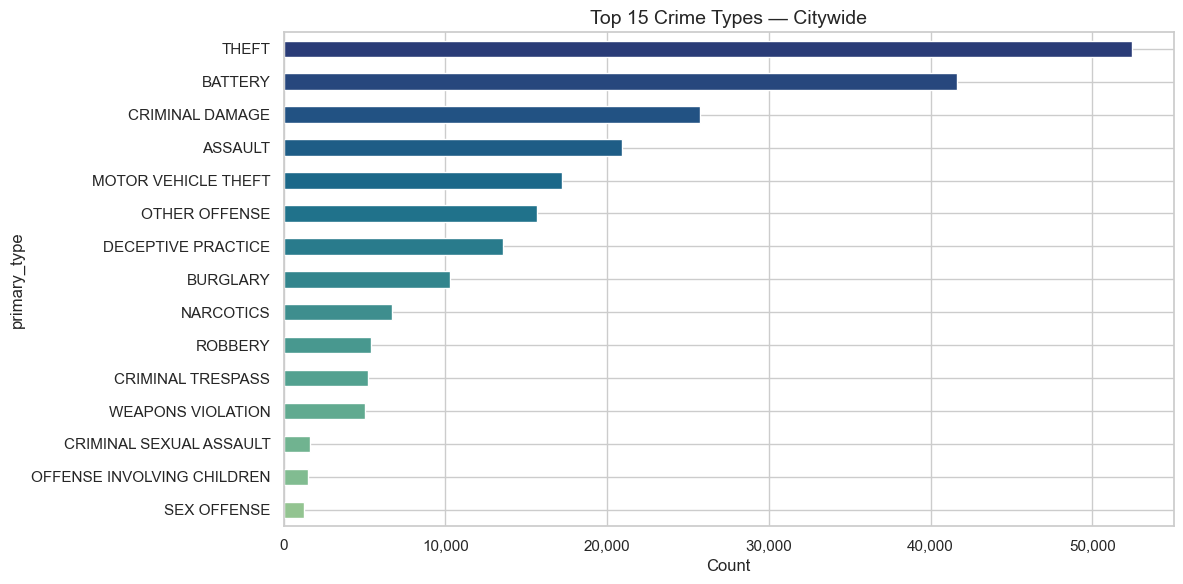

In [10]:
top_types = df['primary_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_types.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('crest', 15))
ax.set_xlabel('Count')
ax.set_title('Top 15 Crime Types — Citywide')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 9. Most Common Crime per Neighborhood

In [11]:
top_crime_per_hood = (
    df.groupby(['neighborhood', 'primary_type'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .groupby('neighborhood')
      .first()
      .reset_index()
      .rename(columns={'primary_type': 'top_crime', 'count': 'occurrences'})
      .sort_values('occurrences', ascending=False)
)

print(top_crime_per_hood[['neighborhood', 'top_crime', 'occurrences']].to_string(index=False))

          neighborhood          top_crime  occurrences
       Near North Side              THEFT         4533
                  Loop              THEFT         3217
        Near West Side              THEFT         2998
                Austin            BATTERY         2549
             Lake View              THEFT         2410
             West Town              THEFT         2161
           South Shore            BATTERY         1744
          Lincoln Park              THEFT         1666
          Logan Square              THEFT         1556
        North Lawndale            BATTERY         1427
Greater Grand Crossing            BATTERY         1381
                Uptown              THEFT         1241
        Auburn Gresham            BATTERY         1188
         Humboldt Park            BATTERY         1146
             Englewood            BATTERY         1099
               Chatham            BATTERY         1071
              Roseland            BATTERY         1026
          

## 10. Top Crime Types per Neighborhood — Heatmap (Top 15 Neighborhoods)

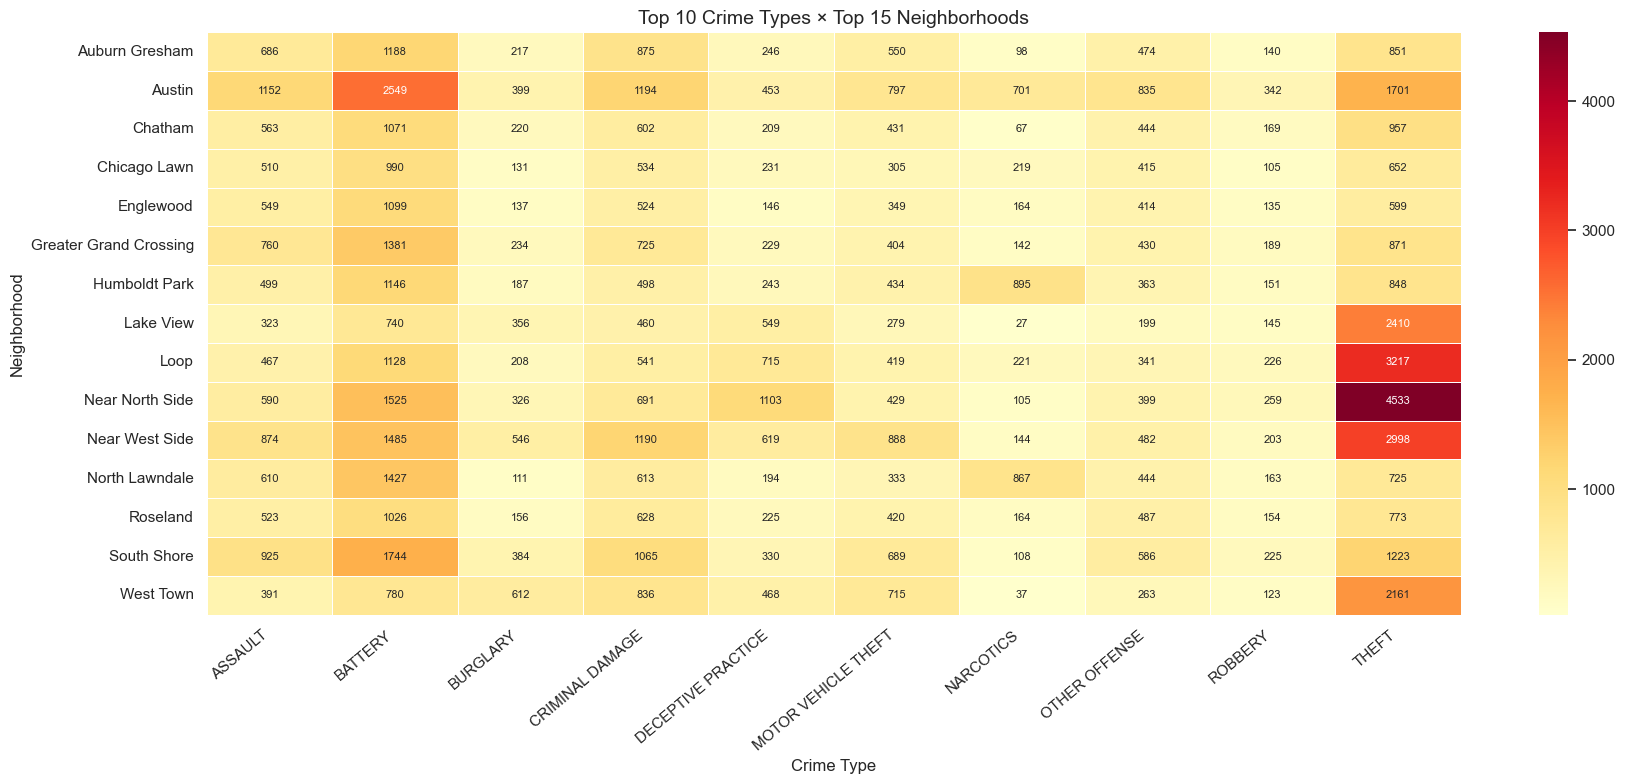

In [12]:
top15_hoods  = df['neighborhood'].value_counts().head(15).index
top10_crimes = df['primary_type'].value_counts().head(10).index

pivot = (
    df[df['neighborhood'].isin(top15_hoods) & df['primary_type'].isin(top10_crimes)]
      .groupby(['neighborhood', 'primary_type'])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    pivot, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Top 10 Crime Types × Top 15 Neighborhoods')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Neighborhood')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## 11. Crime Composition per Neighborhood — 100% Stacked Bar (Top 15 Neighborhoods)

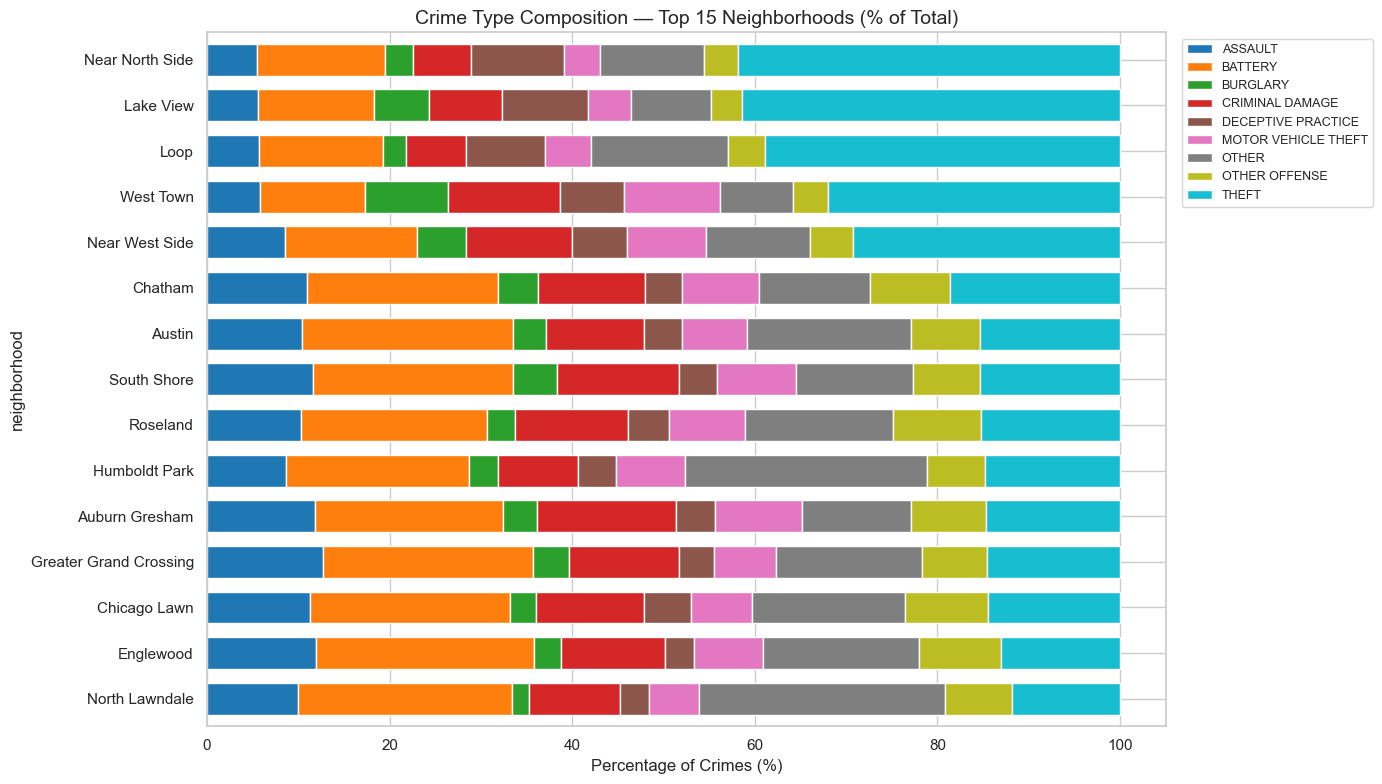

In [13]:
top8 = df['primary_type'].value_counts().head(8).index.tolist()
df['crime_grouped'] = df['primary_type'].where(df['primary_type'].isin(top8), other='OTHER')

composition = (
    df[df['neighborhood'].isin(top15_hoods)]
      .groupby(['neighborhood', 'crime_grouped'])
      .size()
      .unstack(fill_value=0)
)
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
composition_pct.sort_values(top8[0], ascending=True).plot(
    kind='barh', stacked=True, ax=ax, colormap='tab10', width=0.7
)
ax.set_xlabel('Percentage of Crimes (%)')
ax.set_title('Crime Type Composition — Top 15 Neighborhoods (% of Total)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Arrest Rate per Neighborhood — Top 20

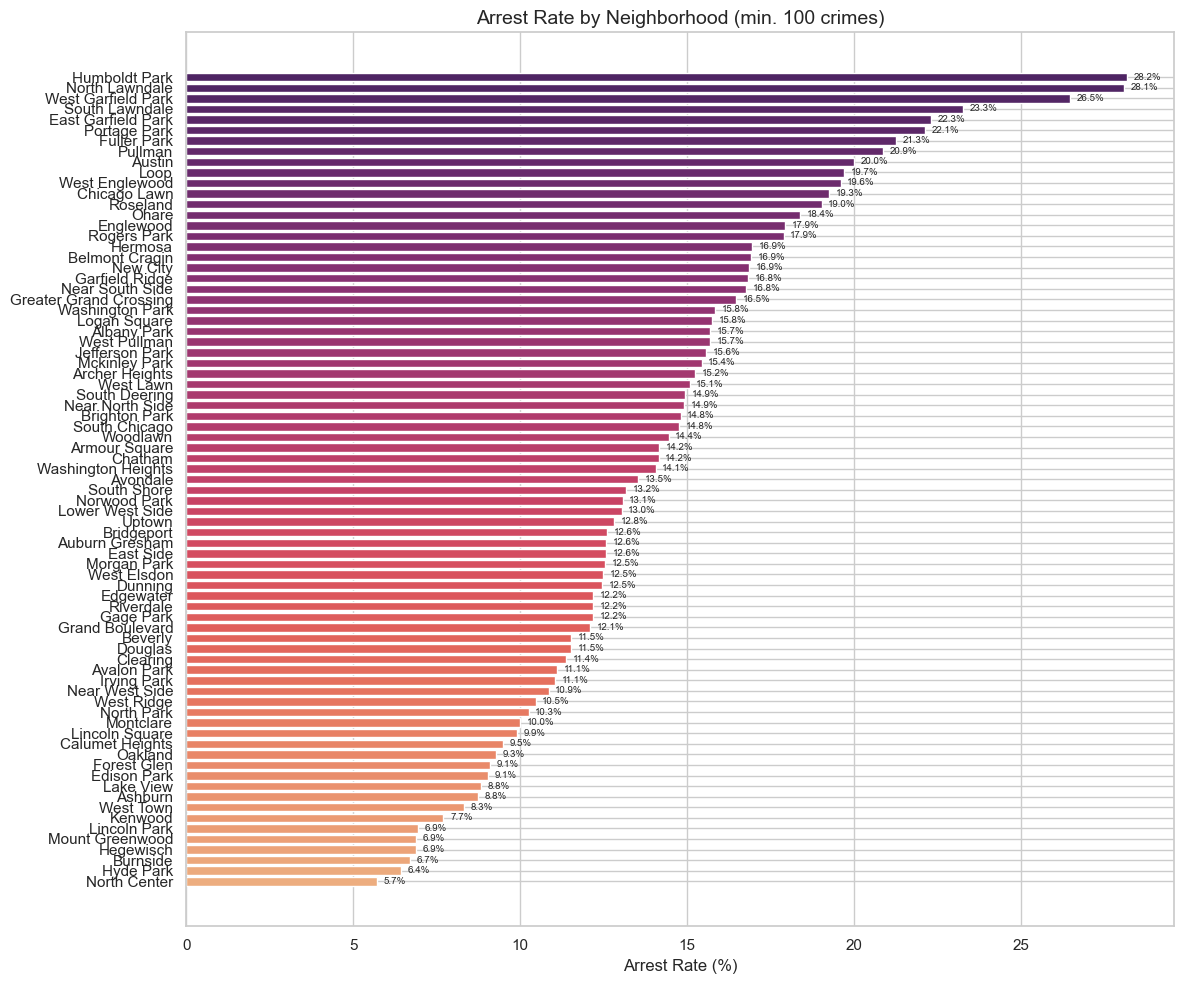

In [14]:
arrest_by_hood = (
    df.groupby('neighborhood')['arrest']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'arrests', 'count': 'total'})
)
arrest_by_hood['arrest_rate_%'] = (arrest_by_hood['arrests'] / arrest_by_hood['total'] * 100).round(2)
# Filter neighborhoods with at least 100 crimes
arrest_by_hood = arrest_by_hood[arrest_by_hood['total'] >= 100].sort_values('arrest_rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(arrest_by_hood.index, arrest_by_hood['arrest_rate_%'],
        color=sns.color_palette('flare', len(arrest_by_hood)))
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Neighborhood (min. 100 crimes)')
for i, val in enumerate(arrest_by_hood['arrest_rate_%']):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=7)
plt.tight_layout()
plt.show()

## 13. Arrest Rate by Crime Type

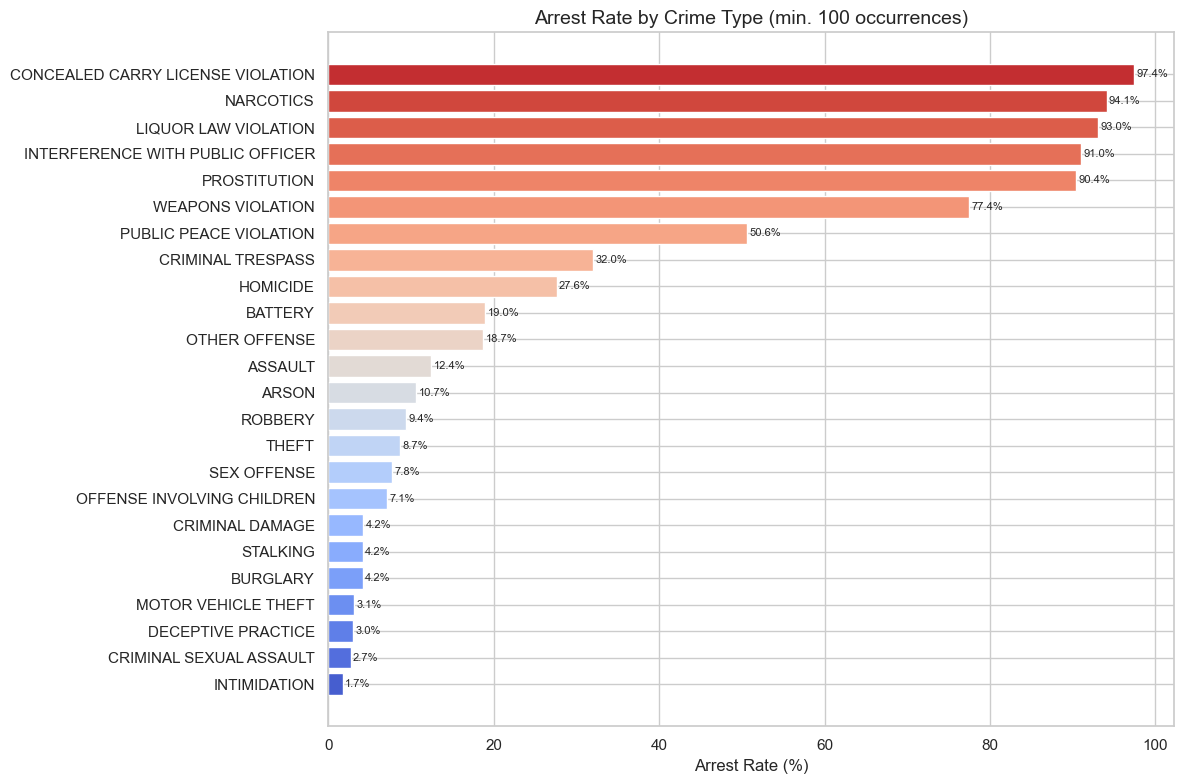

In [15]:
arrest_by_type = (
    df.groupby('primary_type')['arrest']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'arrests', 'count': 'total'})
)
arrest_by_type['arrest_rate_%'] = (arrest_by_type['arrests'] / arrest_by_type['total'] * 100).round(2)
arrest_by_type = arrest_by_type[arrest_by_type['total'] >= 100].sort_values('arrest_rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(arrest_by_type.index, arrest_by_type['arrest_rate_%'],
        color=sns.color_palette('coolwarm', len(arrest_by_type)))
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (min. 100 occurrences)')
for i, val in enumerate(arrest_by_type['arrest_rate_%']):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 14. Domestic vs. Non-Domestic Crimes — Top 15 Neighborhoods

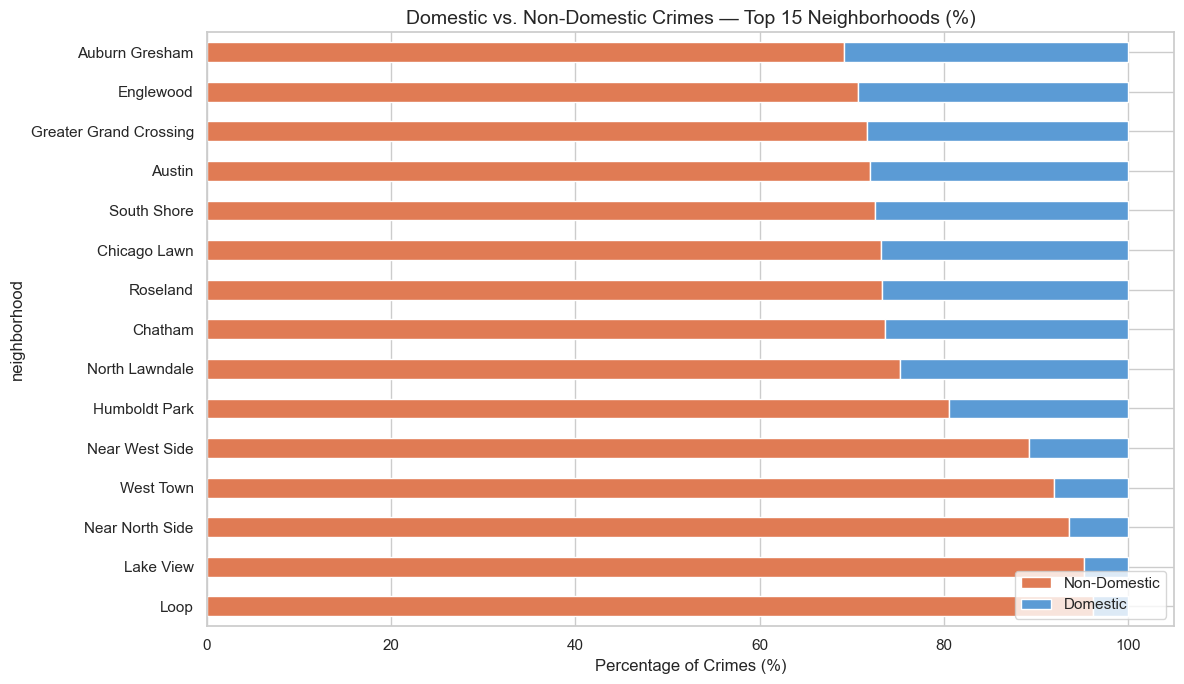

In [16]:
domestic = (
    df[df['neighborhood'].isin(top15_hoods)]
      .groupby(['neighborhood', 'domestic'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={True: 'Domestic', False: 'Non-Domestic'})
)
domestic_pct = domestic.div(domestic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
domestic_pct.sort_values('Domestic', ascending=True).plot(
    kind='barh', stacked=True, ax=ax,
    color=['#e07b54', '#5b9bd5']
)
ax.set_xlabel('Percentage of Crimes (%)')
ax.set_title('Domestic vs. Non-Domestic Crimes — Top 15 Neighborhoods (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 15. Crime by Hour of Day — Citywide

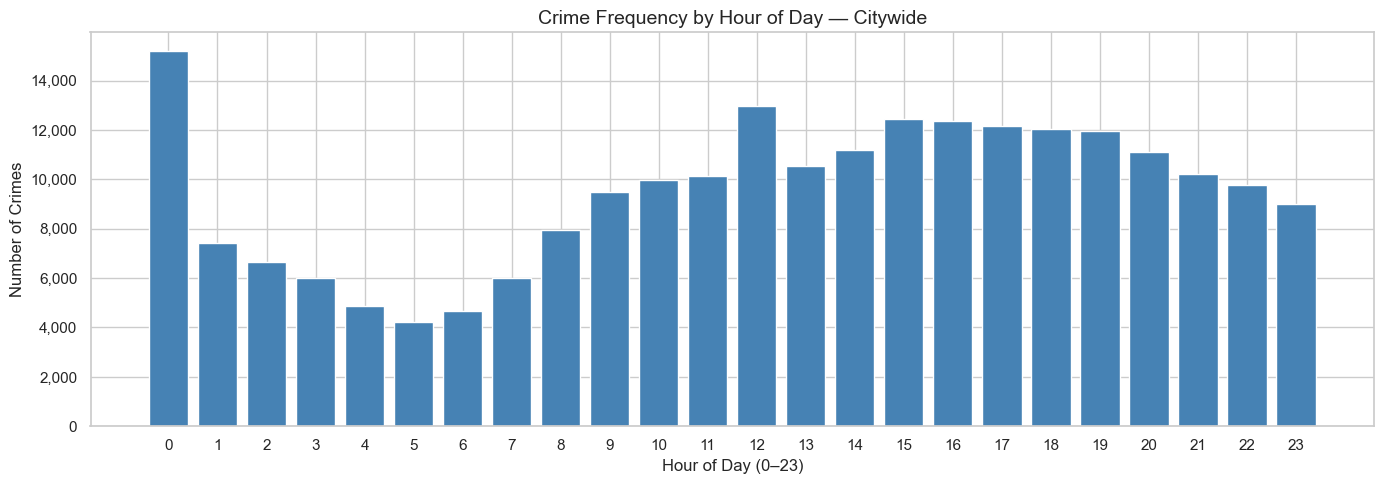

In [17]:
hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly['hour'], hourly['count'], color='steelblue', width=0.8)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Hour of Day — Citywide')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 16. Time of Day by Crime Type

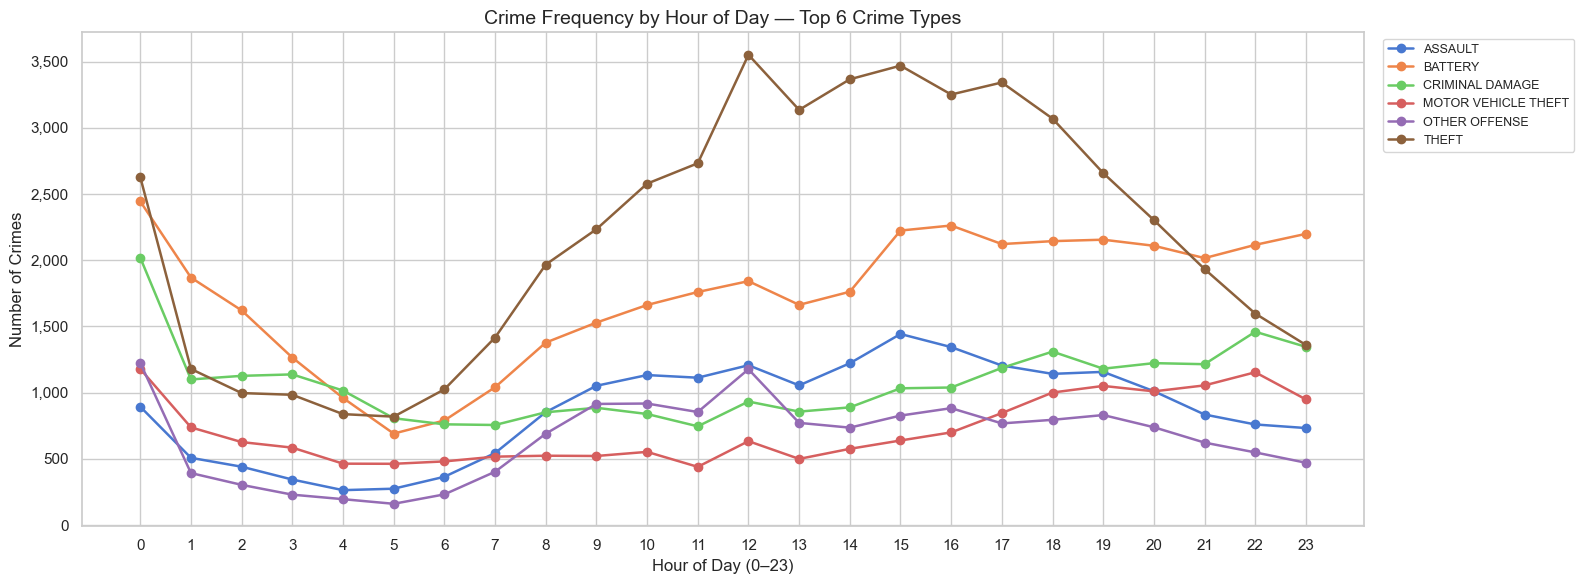

In [18]:
top6_types = df['primary_type'].value_counts().head(6).index.tolist()

hour_by_type = (
    df[df['primary_type'].isin(top6_types)]
      .groupby(['hour', 'primary_type'])
      .size()
      .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(16, 6))
for crime_type, grp in hour_by_type.groupby('primary_type'):
    ax.plot(grp['hour'], grp['count'], marker='o', label=crime_type, linewidth=1.8)

ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Hour of Day — Top 6 Crime Types')
ax.set_xticks(range(0, 24))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 17. Crime by Day of Week — Citywide

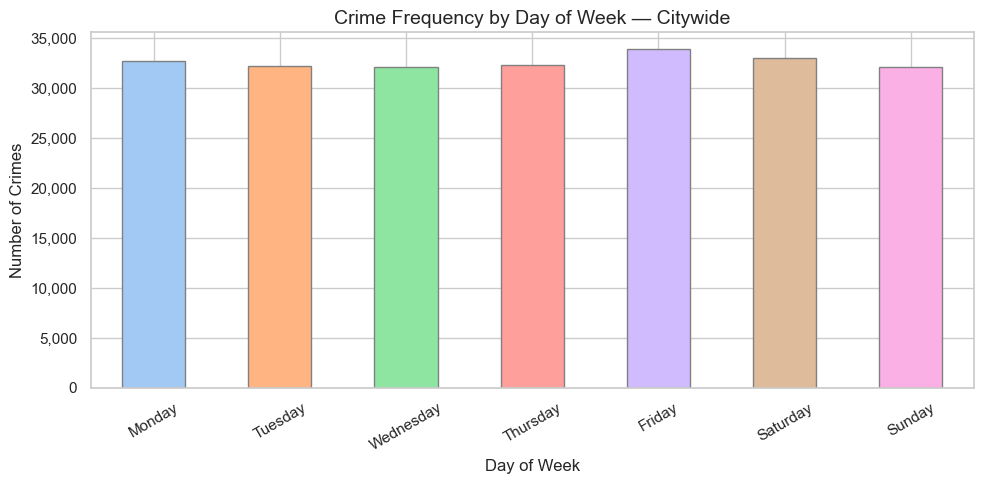

In [19]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
daily.plot(kind='bar', ax=ax, color=sns.color_palette('pastel', 7), edgecolor='grey')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Day of Week — Citywide')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 18. Weekend vs. Weekday Crime Comparison

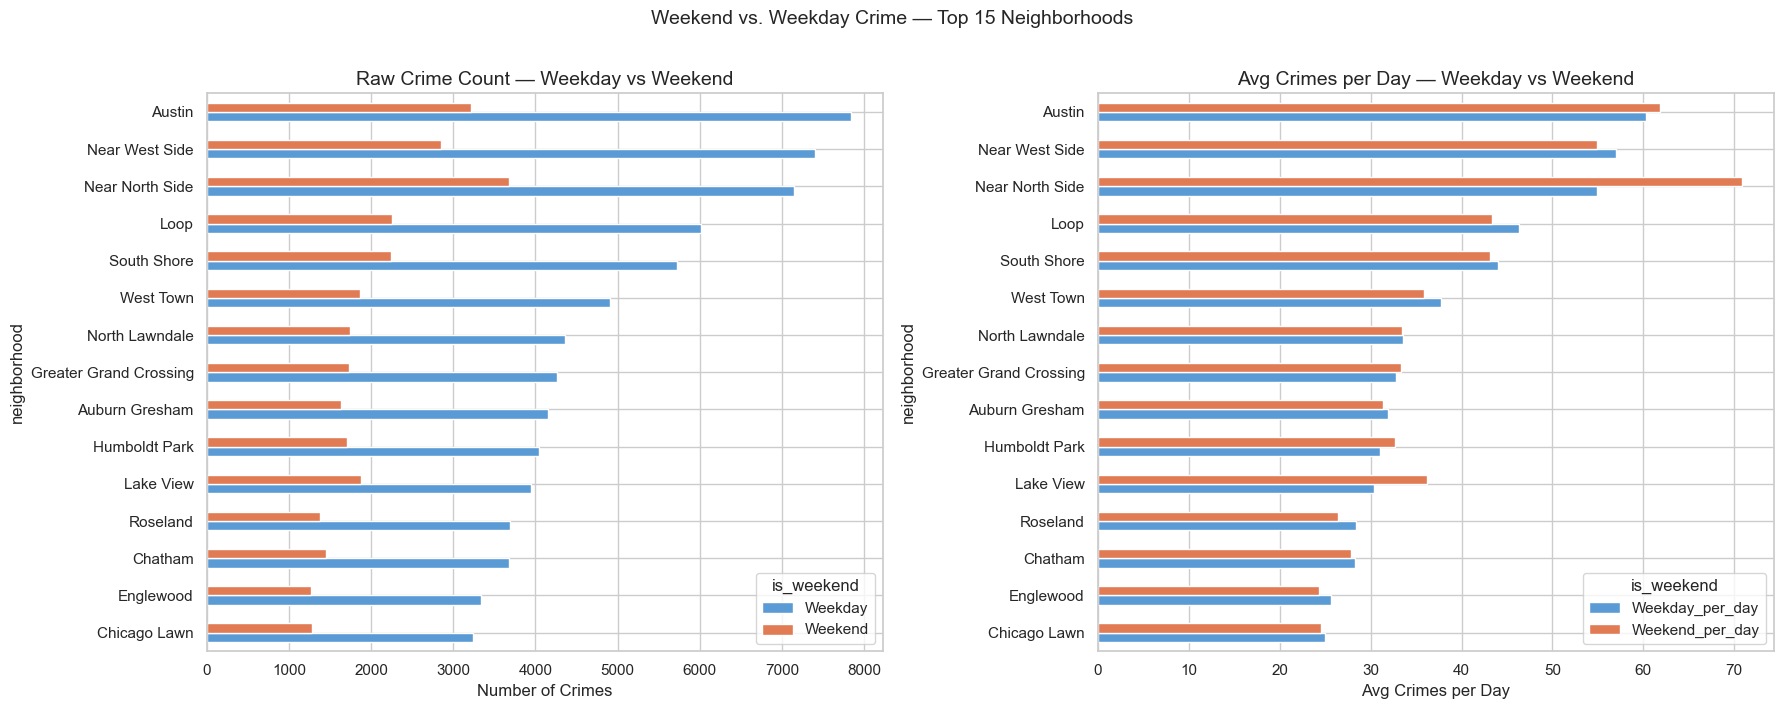

In [20]:
weekend_summary = (
    df[df['neighborhood'].isin(top15_hoods)]
      .groupby(['neighborhood', 'is_weekend'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={False: 'Weekday', True: 'Weekend'})
)

# Normalise by number of days (6 months ≈ 130 weekdays, 52 weekend days)
weekend_summary['Weekday_per_day'] = weekend_summary['Weekday'] / 130
weekend_summary['Weekend_per_day'] = weekend_summary['Weekend'] / 52

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

weekend_summary[['Weekday', 'Weekend']].sort_values('Weekday').plot(
    kind='barh', ax=axes[0], color=['#5b9bd5', '#e07b54']
)
axes[0].set_title('Raw Crime Count — Weekday vs Weekend')
axes[0].set_xlabel('Number of Crimes')

weekend_summary[['Weekday_per_day', 'Weekend_per_day']].sort_values('Weekday_per_day').plot(
    kind='barh', ax=axes[1], color=['#5b9bd5', '#e07b54']
)
axes[1].set_title('Avg Crimes per Day — Weekday vs Weekend')
axes[1].set_xlabel('Avg Crimes per Day')

plt.suptitle('Weekend vs. Weekday Crime — Top 15 Neighborhoods', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 19. Top Location Descriptions (Where Crimes Happen)

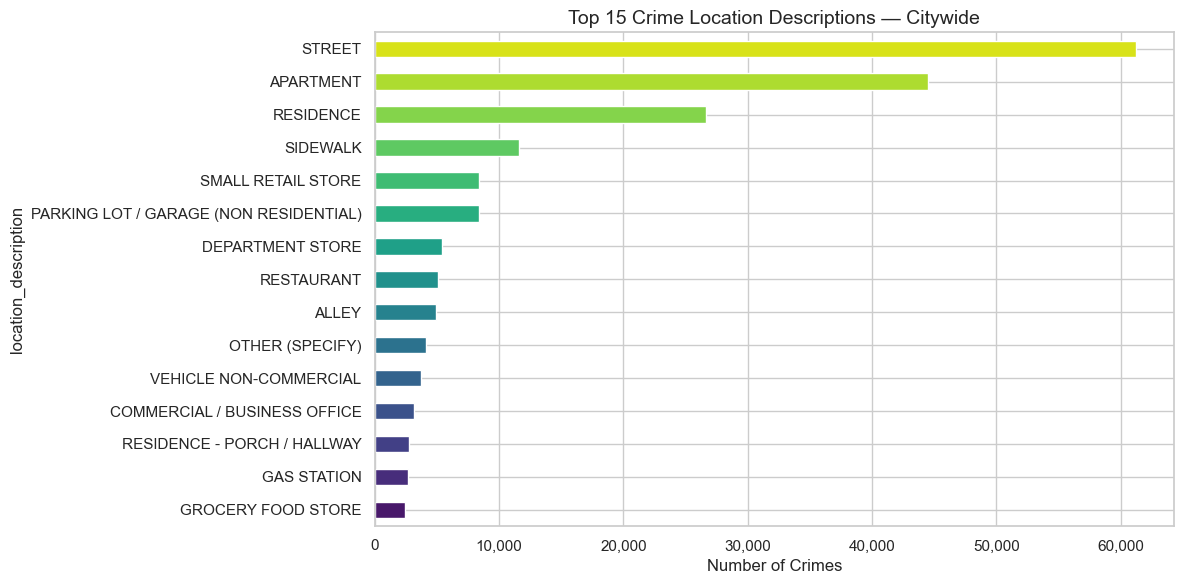

In [21]:
top_locations = df['location_description'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
top_locations.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 15))
ax.set_xlabel('Number of Crimes')
ax.set_title('Top 15 Crime Location Descriptions — Citywide')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 20. Crime Type by Location Description

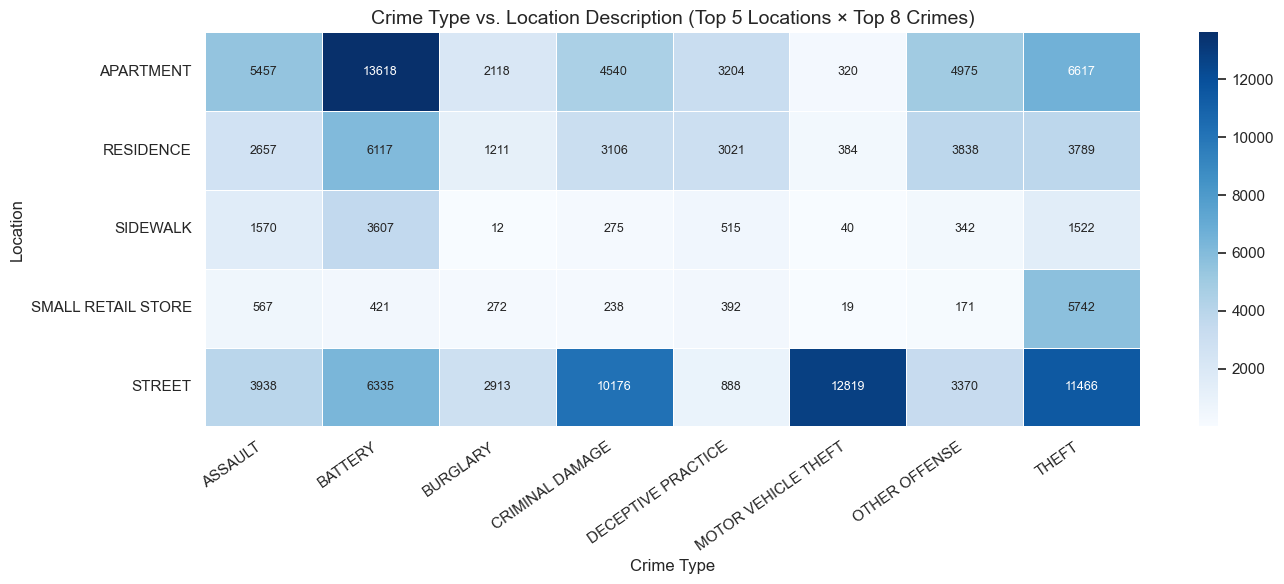

In [22]:
top5_locs   = df['location_description'].value_counts().head(5).index
top8_crimes = df['primary_type'].value_counts().head(8).index

loc_crime = (
    df[df['location_description'].isin(top5_locs) & df['primary_type'].isin(top8_crimes)]
      .groupby(['location_description', 'primary_type'])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    loc_crime, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Crime Type vs. Location Description (Top 5 Locations × Top 8 Crimes)')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Location')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 21. Top Crime-Prone Blocks / Streets — Citywide

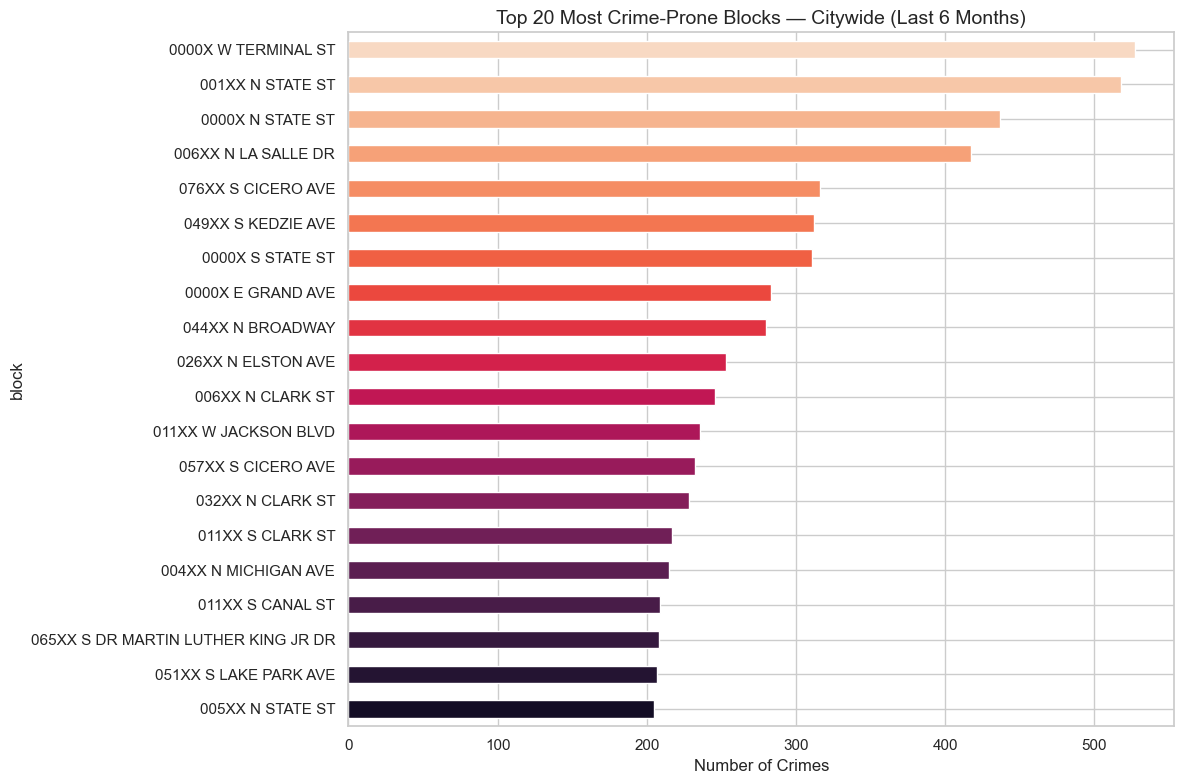

In [23]:
top_blocks = df['block'].value_counts().head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_blocks.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', 20))
ax.set_xlabel('Number of Crimes')
ax.set_title('Top 20 Most Crime-Prone Blocks — Citywide (Last 6 Months)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 22. Top 3 Blocks per Neighborhood

In [24]:
top_block_per_hood = (
    df[df['neighborhood'].isin(top15_hoods)]
      .groupby(['neighborhood', 'block'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .groupby('neighborhood')
      .head(3)
      .sort_values(['neighborhood', 'count'], ascending=[True, False])
)

print(top_block_per_hood.to_string(index=False))

          neighborhood                               block  count
        Auburn Gresham                     012XX W 79TH ST    122
        Auburn Gresham                  078XX S HALSTED ST     71
        Auburn Gresham                     013XX W 76TH ST     60
                Austin                   047XX W NORTH AVE    134
                Austin                  052XX W MADISON ST    134
                Austin                 015XX N CENTRAL AVE    108
               Chatham                     001XX W 87TH ST    117
               Chatham                     0000X W 87TH ST    117
               Chatham                     0000X W 79TH ST    109
          Chicago Lawn                  063XX S KEDZIE AVE    137
          Chicago Lawn                 064XX S WESTERN AVE     60
          Chicago Lawn                     028XX W 63RD ST     58
             Englewood                     002XX W 63RD ST     94
             Englewood                    065XX S LOWE AVE     72
          

## 23. Crimes per Police District

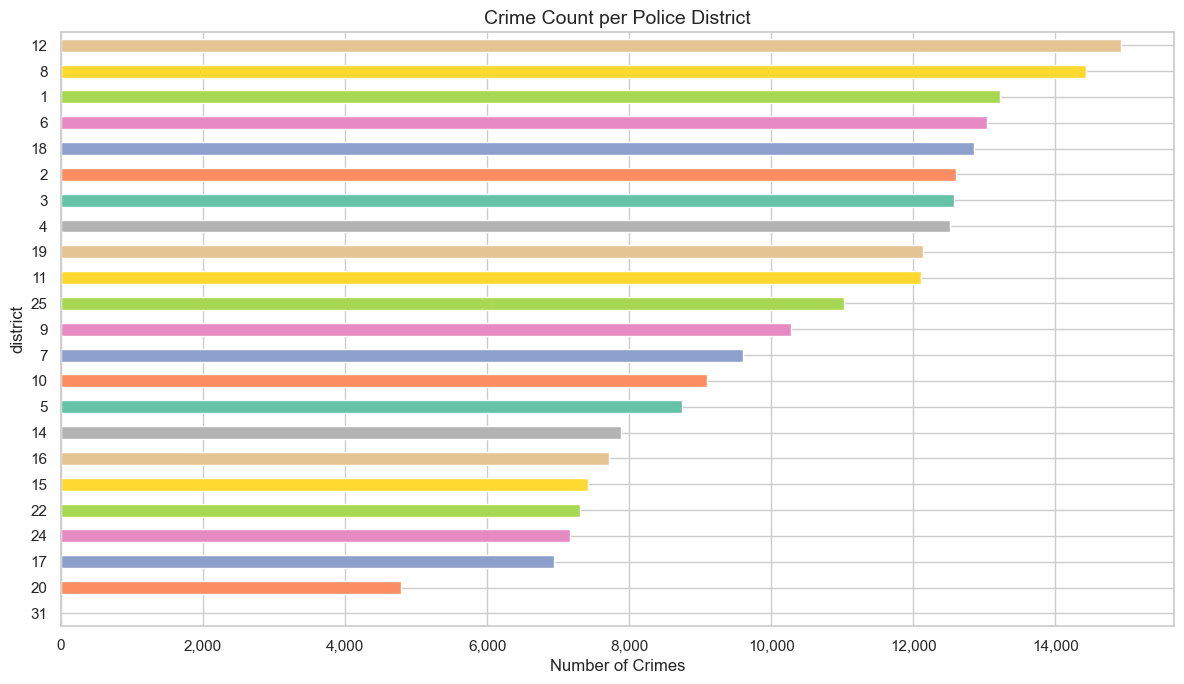

In [25]:
district_counts = df['district'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
district_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(district_counts)))
ax.set_xlabel('Number of Crimes')
ax.set_title('Crime Count per Police District')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 24. Correlation Heatmap (Numeric Features)

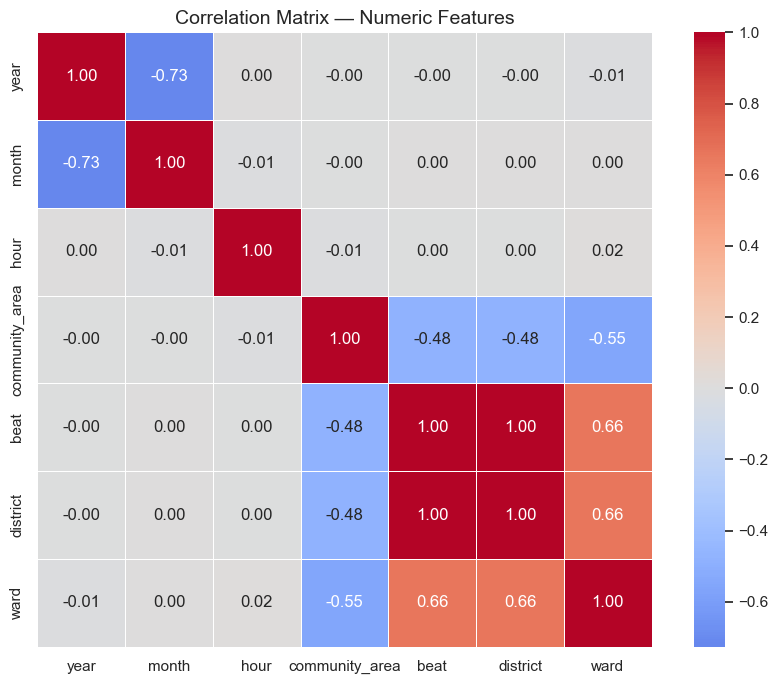

In [26]:
numeric_cols = ['year', 'month', 'hour', 'community_area', 'beat', 'district', 'ward']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

## 25. Summary Statistics Table — All Neighborhoods

In [27]:
summary = (
    df.groupby('neighborhood')
      .agg(
          total_crimes       = ('date', 'count'),
          arrests            = ('arrest', 'sum'),
          domestic_crimes    = ('domestic', 'sum'),
          unique_crime_types = ('primary_type', 'nunique'),
          unique_blocks      = ('block', 'nunique'),
      )
      .reset_index()
)
summary['arrest_rate_%']   = (summary['arrests']         / summary['total_crimes'] * 100).round(2)
summary['domestic_rate_%'] = (summary['domestic_crimes'] / summary['total_crimes'] * 100).round(2)
summary = summary.sort_values('total_crimes', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 140)
print(summary.to_string(index=False))

          neighborhood  total_crimes  arrests  domestic_crimes  unique_crime_types  unique_blocks  arrest_rate_%  domestic_rate_%
                Austin         11056     2213             3095                  27           1039          20.02            27.99
       Near North Side         10826     1615              695                  26            472          14.92             6.42
        Near West Side         10254     1114             1097                  26            899          10.86            10.70
                  Loop          8275     1632              317                  28            316          19.72             3.83
           South Shore          7963     1049             2189                  27            476          13.17            27.49
             West Town          6766      563              541                  26            784           8.32             8.00
        North Lawndale          6100     1714             1509                  25        

## 26. Export Cleaned Data

In [28]:
out_path = '../data/chicago_crimes_citywide.csv'
df.to_csv(out_path, index=False)
print(f'Cleaned data saved to : {out_path}')
print(f'Shape                 : {df.shape}')

Cleaned data saved to : ../data/chicago_crimes_citywide.csv
Shape                 : (101999, 29)


## 27. Per-Community Crime Profile — All Neighborhoods

Descriptive stats grouped only by neighborhood — no year grouping, no filtering.
Each row is one community's full-year crime story.

| Column | What it means |
|---|---|
| `total_incidents` | Total reported crimes |
| `top_crime_types` | Top 3 crime types (by count) |
| `violent_pct` | % of crimes that are violent |
| `domestic_pct` | % flagged as domestic |
| `arrest_rate_pct` | % that resulted in arrest |
| `peak_hour_label` | Hour of day with most incidents |
| `peak_day` | Day of week with most incidents |
| `night_crime_pct` | % happening between 6pm–6am |
| `top_location` | Most common crime location type |
| `peak_month` | Month with most incidents |

In [31]:
# ── helpers ───────────────────────────────────────────────────────────────────
# day_of_week is already a string name (Monday, Tuesday...) in this notebook
# so DAY_MAP is not needed here
MONTH_MAP = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

VIOLENT_TYPES = [
    'HOMICIDE','CRIMINAL SEXUAL ASSAULT','ROBBERY','BATTERY','ASSAULT',
    'KIDNAPPING','STALKING','WEAPONS VIOLATION','SEX OFFENSE'
]

def peak_val(s):   return s.value_counts().idxmax()
def top_n(s, n=3): return ' | '.join(s.value_counts().head(n).index.tolist())
def pct(s):        return round(s.mean() * 100, 1)

# ── derived columns ───────────────────────────────────────────────────────────
df['is_violent']   = df['primary_type'].isin(VIOLENT_TYPES)
df['is_night']     = df['hour'].apply(lambda h: h >= 18 or h < 6)
df['peak_month_n'] = df['month']

# ── aggregate: ALL neighborhoods, no year grouping ───────────────────────────
community_profile = df.groupby('neighborhood').agg(
    total_incidents  = ('primary_type',          'count'),
    top_crime_types  = ('primary_type',          lambda x: top_n(x, 3)),
    violent_pct      = ('is_violent',            pct),
    domestic_pct     = ('domestic',              pct),
    arrest_rate_pct  = ('arrest',                pct),
    peak_hour        = ('hour',                  peak_val),
    peak_day         = ('day_of_week',           peak_val),  # already a string name
    night_crime_pct  = ('is_night',              pct),
    top_location     = ('location_description',  peak_val),
    peak_month       = ('peak_month_n',          peak_val),
).reset_index()

# ── readable labels ───────────────────────────────────────────────────────────
community_profile['peak_month']      = community_profile['peak_month'].map(MONTH_MAP)
community_profile['peak_hour_label'] = community_profile['peak_hour'].apply(
    lambda h: f"{h%12 or 12}{'am' if h<12 else 'pm'}–{(h+1)%12 or 12}{'am' if (h+1)<12 else 'pm'}"
)

community_profile = community_profile.sort_values('total_incidents', ascending=False).reset_index(drop=True)

print(f'Total neighborhoods: {len(community_profile)}')
print()
community_profile[[
    'neighborhood', 'total_incidents', 'top_crime_types',
    'violent_pct', 'domestic_pct', 'arrest_rate_pct',
    'peak_hour_label', 'peak_day', 'night_crime_pct',
    'top_location', 'peak_month'
]]

Total neighborhoods: 78



,neighborhood,total_incidents,top_crime_types,violent_pct,domestic_pct,arrest_rate_pct,peak_hour_label,peak_day,night_crime_pct,top_location,peak_month
0,Austin,11056,BATTERY | THEFT | CRIMINAL DAMAGE,41.4,28.0,20.0,12am–1am,Saturday,48.7,STREET,Jul
1,Near North Side,10826,THEFT | BATTERY | DECEPTIVE PRACTICE,25.1,6.4,14.9,12pm–1pm,Saturday,45.4,STREET,Jul
2,Near West Side,10254,THEFT | BATTERY | CRIMINAL DAMAGE,28.3,10.7,10.9,12am–1am,Friday,45.8,STREET,Jul
3,Loop,8275,THEFT | BATTERY | DECEPTIVE PRACTICE,24.7,3.8,19.7,3pm–4pm,Friday,38.1,STREET,Aug
4,South Shore,7963,BATTERY | THEFT | CRIMINAL DAMAGE,41.2,27.5,13.2,12am–1am,Friday,47.6,APARTMENT,Jul
5,West Town,6766,THEFT | CRIMINAL DAMAGE | BATTERY,21.6,8.0,8.3,12am–1am,Friday,49.1,STREET,Oct
6,North Lawndale,6100,BATTERY | NARCOTICS | THEFT,42.0,24.7,28.1,12pm–1pm,Thursday,47.8,STREET,May
7,Greater Grand Crossing,5992,BATTERY | THEFT | ASSAULT,44.6,28.4,16.5,12am–1am,Monday,48.9,APARTMENT,Jul
8,Lake View,5825,THEFT | BATTERY | DECEPTIVE PRACTICE,23.0,4.8,8.8,12am–1am,Saturday,48.6,STREET,Jun
9,Auburn Gresham,5778,BATTERY | CRIMINAL DAMAGE | THEFT,38.7,30.8,12.6,12am–1am,Monday,48.9,STREET,Jul


In [ ]:
community_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   neighborhood     78 non-null     str    
 1   total_incidents  78 non-null     int64  
 2   top_crime_types  78 non-null     str    
 3   violent_pct      78 non-null     float64
 4   domestic_pct     78 non-null     float64
 5   arrest_rate_pct  78 non-null     float64
 6   peak_hour        78 non-null     int32  
 7   peak_day         0 non-null      str    
 8   night_crime_pct  78 non-null     float64
 9   top_location     78 non-null     str    
 10  peak_month       78 non-null     str    
 11  peak_hour_label  78 non-null     str    
dtypes: float64(4), int32(1), int64(1), str(6)
memory usage: 7.1 KB


In [32]:
community_profile.to_csv('../data/community_crime_profile.csv', index=False)
print(f'Saved: data/community_crime_profile.csv — {len(community_profile)} neighborhoods')


Saved: data/community_crime_profile.csv — 78 neighborhoods
